In [12]:
#importing necessary library
import pandas as pd;
import tensorflow as tf;
from tensorflow import keras;
from keras import Sequential;
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten,Input;
from keras.models import Model;
from tensorflow.keras.preprocessing.image import ImageDataGenerator;
from keras.applications.vgg16 import VGG16;
import matplotlib.pyplot as plt;
from tensorflow.keras.callbacks import EarlyStopping;
from tensorflow.keras.preprocessing import image;
import numpy as np;

In [13]:
#applying data agumentation 
batch_size = 32
train_datagen = ImageDataGenerator(
        rescale=1./255,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True);

test_datagen = ImageDataGenerator(rescale=1./255);

train_generator = train_datagen.flow_from_directory(
        'dataset/train',
        target_size=(150, 150),
        batch_size=batch_size,
        class_mode='categorical');

validation_generator = test_datagen.flow_from_directory(
        'dataset/test',
        target_size=(150, 150),
        batch_size=batch_size,
        class_mode='categorical');

Found 1944 images belonging to 15 classes.
Found 1944 images belonging to 15 classes.


In [26]:
inp =Input(shape=(150,150,3));

In [27]:
#for transfer learning loading pre trained model
conv_base = VGG16(
    weights='imagenet',
    include_top = False, #remove fc layer
    input_tensor=inp
);
conv_base.trainable = False ;

In [28]:
conv_base.summary();

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_9 (InputLayer)        [(None, 150, 150, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 150, 150, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 150, 150, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 75, 75, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 75, 75, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 75, 75, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 37, 37, 128)       0     

In [29]:
# preparing model layer
fla = Flatten()(conv_base.output);
fcl1 = Dense(256, activation='relu')(fla);
outputs = Dense(15, activation='softmax')(fcl1);
model = Model(inputs=inp, outputs=outputs);

In [30]:
model.summary();

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_9 (InputLayer)        [(None, 150, 150, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 150, 150, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 150, 150, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 75, 75, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 75, 75, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 75, 75, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 37, 37, 128)       0   

In [31]:
#compiling with binary crossentropy loss function
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy']);

In [32]:
callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.00001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False
);

In [33]:
#training model with data
history = model.fit(
        train_generator,
        epochs=10,
        callbacks=callback,
        validation_data=validation_generator);

Epoch 1/10
61/61 [==============================] - 21s 267ms/step - loss: 2.0180 - accuracy: 0.3981 - val_loss: 1.1536 - val_accuracy: 0.6610
Epoch 2/10
61/61 [==============================] - 14s 235ms/step - loss: 1.1022 - accuracy: 0.6590 - val_loss: 0.8454 - val_accuracy: 0.7613
Epoch 3/10
61/61 [==============================] - 14s 235ms/step - loss: 0.9111 - accuracy: 0.7222 - val_loss: 0.7827 - val_accuracy: 0.7711
Epoch 4/10
61/61 [==============================] - 14s 235ms/step - loss: 0.7674 - accuracy: 0.7742 - val_loss: 0.6334 - val_accuracy: 0.8128
Epoch 5/10
61/61 [==============================] - 14s 233ms/step - loss: 0.6733 - accuracy: 0.8066 - val_loss: 0.5506 - val_accuracy: 0.8302
Epoch 6/10
61/61 [==============================] - 14s 234ms/step - loss: 0.6038 - accuracy: 0.8210 - val_loss: 0.5869 - val_accuracy: 0.8215
Epoch 7/10
61/61 [==============================] - 14s 233ms/step - loss: 0.5825 - accuracy: 0.8230 - val_loss: 0.4917 - val_accuracy: 0.8529

In [34]:
# calculating accuracy
score = model.evaluate(validation_generator);
print("Loss:", score[0]);
print("Accuracy:", score[1]);

61/61 [==============================] - 7s 116ms/step - loss: 0.4025 - accuracy: 0.8853
Loss: 0.40254539251327515
Accuracy: 0.8852880597114563


In [35]:
#visualizing accuracy and loss

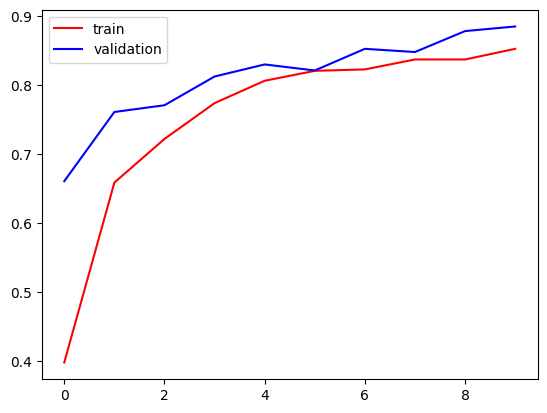

In [36]:
plt.plot(history.history['accuracy'],color='red',label='train');
plt.plot(history.history['val_accuracy'],color='blue',label='validation');
plt.legend();
plt.show();

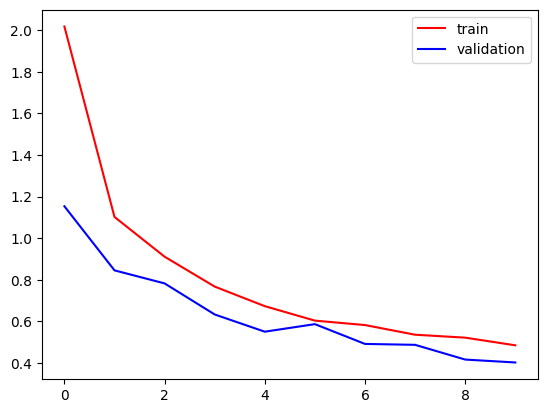

In [37]:
plt.plot(history.history['loss'],color='red',label='train');
plt.plot(history.history['val_loss'],color='blue',label='validation');
plt.legend();
plt.show();

In [38]:
#loading image
img_bear = image.load_img(
    "bear.png",
    target_size=(150,150)
);

img_cat = image.load_img(
    "cat.png",
    target_size=(150,150)
);

D:\SOFTWAARE_RESOURCES\python 3.10.9\lib\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
